Imports

In [1]:
import torch
import torch.nn as nn
from torch.optim import AdamW, LBFGS
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertForSequenceClassification
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve, auc, classification_report
from tqdm.notebook import tqdm
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.manifold import TSNE
import string
from captum.attr import IntegratedGradients
from sklearn.model_selection import train_test_split
import time

Config Variables

In [2]:
MODEL_SELECT = 'bert'
# MODEL_SELECT = 'roberta'

SELECTED_DATASET = 'semeval2014'
# SELECTED_DATASET = 'semeval2015'

SELECTED_DATA_TYPE = 'laptops'
# SELECTED_DATA_TYPE = 'restaurants'

In [3]:
DATA_2014_PATH = "data/semeval2014/"
DATA_2015_PATH = "data/semeval2015/"

MODEL_SAVED_PATH = 'model/' + MODEL_SELECT + '/'
if MODEL_SELECT == 'bert':
    MODEL_NAME = "bert-base-uncased"
elif MODEL_SELECT == 'roberta':
    MODEL_NAME = "roberta-base"
else:
    raise ValueError("MODEL_SELECT is not supported.")
BATCH_SIZE  = 16
LR          = 2e-5
WEIGHT_DECAY = 1e-5
EPOCHS      = 10
MAX_LEN     = 128
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
SEED        = 42

POLARITY2LABEL = {"negative": 0, "neutral": 1, "positive": 2}

print(DEVICE)

cuda


Data Loading & Preprocessing

In [4]:
# Data path
DATA_PATH = f"data/{SELECTED_DATASET}/"
if SELECTED_DATA_TYPE == 'laptops':
    TRAIN_PATH = DATA_PATH + 'Laptops_Train.csv'
    TEST_PATH  = DATA_PATH + 'Laptops_Test.csv'
elif SELECTED_DATA_TYPE == 'restaurants':
    TRAIN_PATH = DATA_PATH + 'Restaurants_Train.csv'
    TEST_PATH  = DATA_PATH + 'Restaurants_Test.csv'
else:
    raise ValueError("Selected data type must be 'laptops' or 'restaurants'")

# Is random sampling
RANDOM_SPLIT = True  # False: Use the first n data

In [5]:
"""Unified Loading and Preprocessing"""
def load_and_unify(path, task):
    df = pd.read_csv(path)
    if task == 'semeval2014':
        df = df.rename(columns={
            "Sentence": "sentence",
            "Aspect Term": "aspect",
            "polarity": "polarity",
            "from": "from_idx",
            "to": "to_idx"
        })
    elif task == 'semeval2015':
        df = df.rename(columns={
            "text": "sentence",
            "target": "aspect",
            "polarity": "polarity",
            "from_num": "from_idx",
            "to_num": "to_idx",
            "review_id": "id"
        })
    else:
        raise ValueError("Task must be 'semeval2014' or 'semeval2015'")
    df = df[["id","sentence","aspect","polarity","from_idx","to_idx"]]
    df["label"] = df["polarity"].map(POLARITY2LABEL)
    df = df.dropna(subset=["label"]).reset_index(drop=True)
    df["label"] = df["label"].astype(int)
    df["sentence"] = df["sentence"].fillna("").astype(str)
    df["aspect"]   = df["aspect"].fillna("").astype(str)
    return df

# Load data
data_train = load_and_unify(TRAIN_PATH, SELECTED_DATASET)
data_test  = load_and_unify(TEST_PATH, SELECTED_DATASET) if SELECTED_DATASET=='semeval2015' else None

"""Split into Training/Test Sets"""
# Hyperparameters
RANDOM_SPLIT    = True   # True for random split, False for sequential
EQUALIZE        = True   # True to equalize class distribution
REPLACE         = False  # True to allow replacement when sampling shortage
TRAIN_SIZE      = 1600
TEST_SIZE       = 400

# Derived values
NUM_CLASSES = len(POLARITY2LABEL)
BASE_TR     = TRAIN_SIZE // NUM_CLASSES
REM_TR      = TRAIN_SIZE % NUM_CLASSES
BASE_TE     = TEST_SIZE  // NUM_CLASSES
REM_TE      = TEST_SIZE  % NUM_CLASSES

# 1) Proportional fallback when total available < required
def proportional_split(df, train_size, test_size):
    total = len(df)
    required = train_size + test_size
    if total < required:
        print(f"⚠️ Requested {required} > available {total}. Using full data proportional stratified split.")
        frac_tr = train_size / required
        tr, te = train_test_split(
            df, train_size=frac_tr,
            stratify=df['label'], random_state=SEED
        )
        return tr.reset_index(drop=True), te.reset_index(drop=True)
    return None, None

# 2) SemEval-2014 split logic
def split_2014(df):
    # fallback
    pf = proportional_split(df, TRAIN_SIZE, TEST_SIZE)
    if pf[0] is not None:
        return pf

    if EQUALIZE:
        # dynamic equalization without replacement
        parts_tr = []
        shortfall = 0
        avail = []
        for idx, lbl in enumerate(sorted(POLARITY2LABEL.values())):
            desired = BASE_TR + (1 if idx < REM_TR else 0)
            sub = df[df['label']==lbl]
            take = min(desired, len(sub))
            parts_tr.append(
                sub.sample(n=take, replace=False, random_state=SEED)
            )
            if len(sub) > take:
                avail.append(lbl)
            shortfall += (desired - take)
        if shortfall > 0:
            print(f"⚠️ Classes exhausted in train split; refilling {shortfall} samples.")
        for i in range(shortfall):
            lbl = avail[i % len(avail)]
            src = df[df['label']==lbl].drop(
                pd.concat(parts_tr).index, errors='ignore'
            )
            parts_tr.append(src.sample(n=1, random_state=SEED+i))
        train_df = pd.concat(parts_tr).sample(frac=1, random_state=SEED).reset_index(drop=True)

        # test dynamic equalization
        parts_te = []
        shortfall_te = 0
        avail_te = []
        remain = df.drop(train_df.index)
        for idx, lbl in enumerate(sorted(POLARITY2LABEL.values())):
            desired = BASE_TE + (1 if idx < REM_TE else 0)
            sub = remain[remain['label']==lbl]
            take = min(desired, len(sub))
            parts_te.append(
                sub.sample(n=take, replace=False, random_state=SEED)
            )
            if len(sub) > take:
                avail_te.append(lbl)
            shortfall_te += (desired - take)
        if shortfall_te > 0:
            print(f"⚠️ Classes exhausted in test split; refilling {shortfall_te} samples.")
        for i in range(shortfall_te):
            lbl = avail_te[i % len(avail_te)]
            src = remain.drop(
                pd.concat(parts_te).index, errors='ignore'
            )
            src = src[src['label']==lbl]
            parts_te.append(src.sample(n=1, random_state=SEED+100+i))
        test_df = pd.concat(parts_te).sample(frac=1, random_state=SEED).reset_index(drop=True)
        return train_df, test_df

    # stratified split
    return train_test_split(
        df,
        train_size=TRAIN_SIZE,
        test_size=TEST_SIZE,
        stratify=df['label'],
        random_state=SEED
    )

# 3) SemEval-2015 split logic: combine train/test files
def split_2015(df_train, df_test):
    df_all = pd.concat([df_train, df_test]).reset_index(drop=True)
    pf = proportional_split(df_all, TRAIN_SIZE, TEST_SIZE)
    if pf[0] is not None:
        return pf
    if EQUALIZE:
        return split_2014(df_all)
    return train_test_split(
        df_all,
        train_size=TRAIN_SIZE,
        test_size=TEST_SIZE,
        stratify=df_all['label'],
        random_state=SEED
    )

# 4) Dispatch based on dataset
if SELECTED_DATASET=='semeval2014':
    train_df, test_df = split_2014(data_train)
elif SELECTED_DATASET=='semeval2015':
    train_df, test_df = split_2015(data_train, data_test)
else:
    raise ValueError("Unsupported dataset")

# 5) Print results
print(f"Train: {len(train_df)}, Test: {len(test_df)}")
print("Train distribution:", train_df['label'].value_counts(normalize=True).to_dict())
print("Test distribution: ", test_df['label'].value_counts(normalize=True).to_dict())

⚠️ Classes exhausted in train split; refilling 73 samples.
Train: 1600, Test: 400
Train distribution: {0: 0.356875, 2: 0.355625, 1: 0.2875}
Test distribution:  {0: 0.335, 1: 0.3325, 2: 0.3325}


In [6]:
print("Train len:", train_df['label'].value_counts())
print("Test len: ", test_df['label'].value_counts())
print(f"Full train samples: {len(data_train)}")

Train len: label
0    571
2    569
1    460
Name: count, dtype: int64
Test len:  label
0    134
1    133
2    133
Name: count, dtype: int64
Full train samples: 2313


Dataset & DataLoader

In [7]:
class ABSADataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        encoding = self.tokenizer(
            text=row["sentence"],
            text_pair=row["aspect"],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels":         torch.tensor(row["label"], dtype=torch.long)
        }

if MODEL_SELECT == 'bert':
    tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
elif MODEL_SELECT == 'roberta':
    tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)
else:
    raise ValueError("MODEL_SELECT is not supported.")

# Training set
train_dataset = ABSADataset(train_df, tokenizer, MAX_LEN)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Test set
test_dataset  = ABSADataset(test_df, tokenizer, MAX_LEN)
test_loader   = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Model, Optimizer & Training Utilities

In [8]:
if MODEL_SELECT == 'bert':
    model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(POLARITY2LABEL)
).to(DEVICE)
elif MODEL_SELECT == 'roberta':
    model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(POLARITY2LABEL)
).to(DEVICE)
else:
    raise ValueError("MODEL_SELECT is not supported.")
optimizer = AdamW(model.parameters(), lr=LR)


def train_epoch(model, train_loader, optimizer, device, epoch, total_epochs):
    model.train()
    total_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Train Epoch {epoch}/{total_epochs}", leave=True)
    for batch in pbar:
        optimizer.zero_grad()
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix(loss=total_loss / (pbar.n + 1))
    pbar.close()
    return total_loss / len(train_loader)


def eval_model(model, eval_loader, device, epoch, total_epochs):
    model.eval()
    preds, golds = [], []
    pbar = tqdm(eval_loader, desc=f"Eval  Epoch {epoch}/{total_epochs}", leave=True)
    with torch.no_grad():
        for batch in pbar:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits
            preds.extend(torch.argmax(logits, dim=1).cpu().tolist())
            golds.extend(labels.cpu().tolist())
    pbar.close()
    return f1_score(golds, preds, average="macro")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Main Training Loop

In [9]:
t1 = time.time()
history = []
best_f1 = 0.0
for epoch in range(1, EPOCHS + 1):
    avg_loss = train_epoch(model, train_loader, optimizer, DEVICE, epoch, EPOCHS)
    # Evaluate with train_loader after each epoch
    f1_score_epoch = eval_model(model, train_loader, DEVICE, epoch, EPOCHS)

    print(f"Epoch {epoch} — loss: {avg_loss:.4f}, macro-F1: {f1_score_epoch:.4f}")

    history.append({
        "epoch": epoch,
        "loss": avg_loss,
        "f1": f1_score_epoch
    })

    if f1_score_epoch > best_f1:
        best_f1 = f1_score_epoch
        spath = os.path.join(MODEL_SAVED_PATH, SELECTED_DATASET, SELECTED_DATA_TYPE)
        model.save_pretrained(spath)
        tokenizer.save_pretrained(spath)

save_dir = os.path.join(MODEL_SAVED_PATH, SELECTED_DATASET, SELECTED_DATA_TYPE)
os.makedirs(save_dir, exist_ok=True)

df_history = pd.DataFrame(history)
df_history.to_csv(os.path.join(save_dir, "training_history.csv"), index=False)

with open(os.path.join(save_dir, "training_history.json"), "w") as f:
    json.dump(history, f, indent=4)
runtime = time.time() - t1
print(runtime)

Train Epoch 1/10:   0%|          | 0/100 [00:00<?, ?it/s]

Eval  Epoch 1/10:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1 — loss: 0.8612, macro-F1: 0.7800


Train Epoch 2/10:   0%|          | 0/100 [00:00<?, ?it/s]

Eval  Epoch 2/10:   0%|          | 0/100 [00:00<?, ?it/s]

...

Eval  Epoch 9/10:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 9 — loss: 0.0523, macro-F1: 0.9891


Train Epoch 10/10:   0%|          | 0/100 [00:00<?, ?it/s]

Eval  Epoch 10/10:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 10 — loss: 0.0475, macro-F1: 0.9903


Test Module

In [10]:
df_test = test_df
df_test = df_test.dropna(subset=["sentence","aspect","label"]).reset_index(drop=True)

model_dir = os.path.join(MODEL_SAVED_PATH, SELECTED_DATASET, SELECTED_DATA_TYPE)

if MODEL_SELECT == 'bert':
    model = BertForSequenceClassification.from_pretrained(model_dir).to(DEVICE)
elif MODEL_SELECT == 'roberta':
    model = RobertaForSequenceClassification.from_pretrained(model_dir).to(DEVICE)
else:
    raise ValueError("MODEL_SELECT is not supported.")
model.eval()

all_preds, all_labels = [], []
for batch in tqdm(test_loader, desc="Test", leave=True):
    input_ids      = batch["input_ids"].to(DEVICE)
    attention_mask = batch["attention_mask"].to(DEVICE)
    labels         = batch["labels"].to(DEVICE)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    preds = torch.argmax(outputs.logits, dim=1)

    all_preds.extend(preds.cpu().tolist())
    all_labels.extend(labels.cpu().tolist())


macro_f1 = f1_score(all_labels, all_preds, average="macro")
report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=[k for k,v in sorted(POLARITY2LABEL.items(), key=lambda x:x[1])],
    output_dict=True,
    zero_division=0
)


with open(os.path.join(save_dir, "test_results.json"), "w") as f:
    json.dump({
        "macro_f1": macro_f1,
        "classification_report": report_dict
    }, f, indent=4)


df_preds = pd.DataFrame({
    "true_label": all_labels,
    "predicted_label": all_preds
})
df_preds.to_csv(os.path.join(save_dir, "test_predictions.csv"), index=False)

print("df_test rows:", len(df_test))
print("test_loader samples:", len(test_loader.dataset))
print(f"Test macro-F1: {macro_f1:.4f}")

Test:   0%|          | 0/25 [00:00<?, ?it/s]

df_test rows: 400
test_loader samples: 400
Test macro-F1: 0.9379


xAI Explainability

Explain Instances:   0%|          | 0/50 [00:00<?, ?it/s]

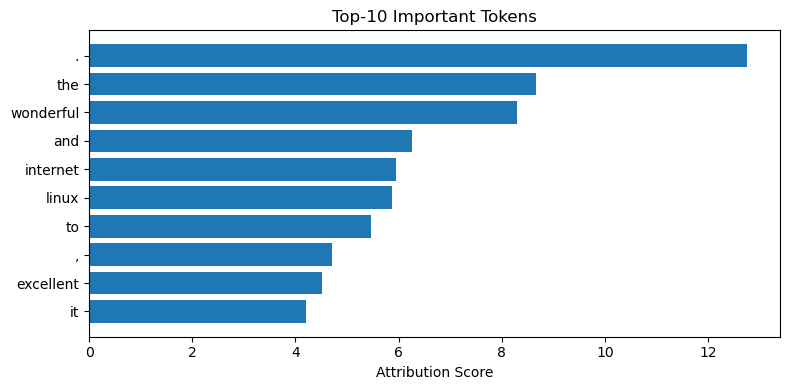

In [11]:
# Helper function: filter padding and special token
def filter_tokens(tokens, attributions, attention_mask, tokenizer):
    keep = []
    mask = attention_mask.squeeze().cpu().numpy()
    for tok, attr, m in zip(tokens, attributions, mask):
        if m == 1 and tok not in {tokenizer.pad_token, tokenizer.cls_token, tokenizer.sep_token}:
            keep.append((tok, attr))
    if not keep:
        return tokens, attributions
    toks, attrs = zip(*keep)
    return list(toks), np.array(attrs)

def filter_tokens_punctuation(tokens, attributions, attention_mask, tokenizer):
    keep = []
    mask = attention_mask.squeeze().cpu().numpy()
    for tok, attr, m in zip(tokens, attributions, mask):
        # Skip padding, special tokens, and pure punctuation
        if m == 1 \
           and tok not in {tokenizer.pad_token, tokenizer.cls_token, tokenizer.sep_token} \
           and not all(c in string.punctuation for c in tok):
            keep.append((tok, attr))
    if not keep:
        return tokens, attributions
    toks, attrs = zip(*keep)
    return list(toks), np.array(attrs)

# Helper function: merging subwords
def merge_subwords(tokens, attributions):
    merged_tokens, merged_attrs = [], []
    buffer_tok, buffer_attr = "", 0.0
    for tok, attr in zip(tokens, attributions):
        if tok.startswith("##") or tok.startswith("Ġ"):
            buffer_tok += tok.lstrip("#Ġ")
            buffer_attr += attr
        else:
            if buffer_tok:
                merged_tokens.append(buffer_tok)
                merged_attrs.append(buffer_attr)
            buffer_tok, buffer_attr = tok, attr
    if buffer_tok:
        merged_tokens.append(buffer_tok)
        merged_attrs.append(buffer_attr)
    return merged_tokens, np.array(merged_attrs)

# Define forward_for_ig
def forward_for_ig(inputs_embeds, attention_mask):
    outputs = model(inputs_embeds=inputs_embeds, attention_mask=attention_mask)
    return outputs.logits

# Initialize the IG interpreter
ig = IntegratedGradients(forward_for_ig)

# Single sample explanation function (including filtering and merging 'modify position')
def explain_instance(sentence, aspect, tokenizer, model, ig, max_len, device):
    model.eval()
    inputs = tokenizer(
        sentence,
        text_pair=aspect,
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors='pt'
    )
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    embedding_layer = model.get_input_embeddings()
    inputs_embeds = embedding_layer(input_ids)
    ref_input_ids = torch.full_like(input_ids, tokenizer.pad_token_id)
    ref_embeds = embedding_layer(ref_input_ids.to(device))

    # Prediction
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        pred = torch.argmax(outputs.logits, dim=1).item()
        probs = torch.softmax(outputs.logits, dim=1)
        pred_prob = probs[0, pred].item()

    #IG Attribution
    attributions, delta = ig.attribute(
        inputs=inputs_embeds,
        baselines=ref_embeds,
        additional_forward_args=(attention_mask,),
        target=pred,
        return_convergence_delta=True
    )
    attributions = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze().cpu().tolist())

    # Modify position: filter padding and special token
    tokens, attributions = filter_tokens(tokens, attributions, attention_mask, tokenizer)
    # tokens, attributions = filter_tokens_punctuation(tokens, attributions, attention_mask, tokenizer)

    # Modify position: merge subwords
    tokens, attributions = merge_subwords(tokens, attributions)

    return tokens, attributions, pred, pred_prob, delta.item()

# Batch collect explanation results and display progress
explanations = []
samples = df_test.sample(n=min(50, len(df_test)), random_state=SEED)
for _, row in tqdm(samples.iterrows(), total=len(samples), desc="Explain Instances", leave=True):
    tokens, attr_vals, pred, pred_prob, delta = explain_instance(
        row['sentence'], row['aspect'], tokenizer, model, ig, MAX_LEN, DEVICE
    )
    explanations.append({
        'id': int(row['id']),
        'sentence': row['sentence'],
        'aspect': row['aspect'],
        'true_label': row['label'],
        'predicted_label': pred,
        'pred_prob': pred_prob,
        'tokens': tokens,
        'attributions': attr_vals.tolist(),
        'convergence_delta': delta
    })

# Save the explanation results
exp_path = os.path.join(save_dir, 'explanations.json')
with open(exp_path, 'w', encoding='utf-8') as f:
    json.dump(explanations, f, indent=2, ensure_ascii=False)

# Top-K important token histogram
top_k = 10
# Aggregate all sample scores
token_scores = {}
for exp in explanations:
    for tok, score in zip(exp['tokens'], exp['attributions']):
        token_scores[tok] = token_scores.get(tok, 0) + abs(score)
# Sort and take top_k
top = sorted(token_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
k_tokens, k_scores = zip(*top)
plt.figure(figsize=(8,4))
plt.barh(list(k_tokens)[::-1], list(k_scores)[::-1])
plt.xlabel('Attribution Score')
plt.title(f'Top-{top_k} Important Tokens')
plt.tight_layout()
plt.show()

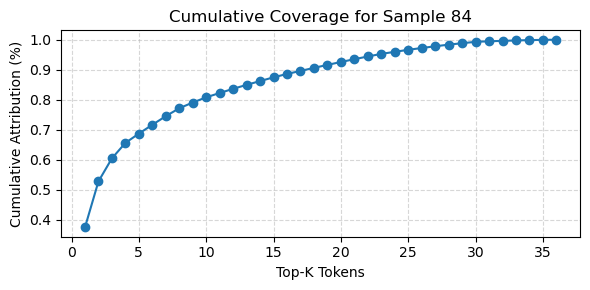

In [12]:
# Cumulative attribution coverage curve
# Measures how much of the total attribution can be covered by the attribution of the top K most important tokens for a sentence
exp0 = explanations[0]
attrs = np.abs(exp0['attributions'])
sorted_idx = np.argsort(-attrs)
cum = np.cumsum(attrs[sorted_idx]) / attrs.sum()

plt.figure(figsize=(6,3))
plt.plot(np.arange(1, len(cum)+1), cum, marker='o')
plt.xlabel("Top-K Tokens")
plt.ylabel("Cumulative Attribution (%)")
plt.title(f"Cumulative Coverage for Sample {exp0['id']}")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Comprehensive Visualizations

In [13]:
# Common paths and data loading
save_dir = os.path.join(MODEL_SAVED_PATH, SELECTED_DATASET, SELECTED_DATA_TYPE)


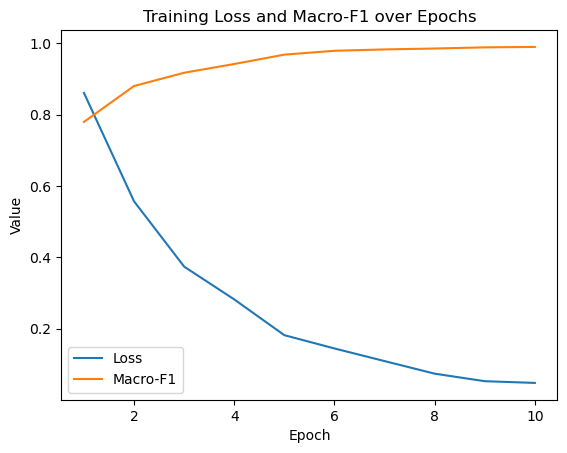

In [14]:
# A: Training Curves (Loss & F1 over Epochs)
df_hist = pd.read_csv(os.path.join(save_dir, "training_history.csv"))
plt.figure()
plt.plot(df_hist["epoch"], df_hist["loss"], label="Loss")
plt.plot(df_hist["epoch"], df_hist["f1"], label="Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Loss and Macro-F1 over Epochs")
plt.legend()
plt.show()


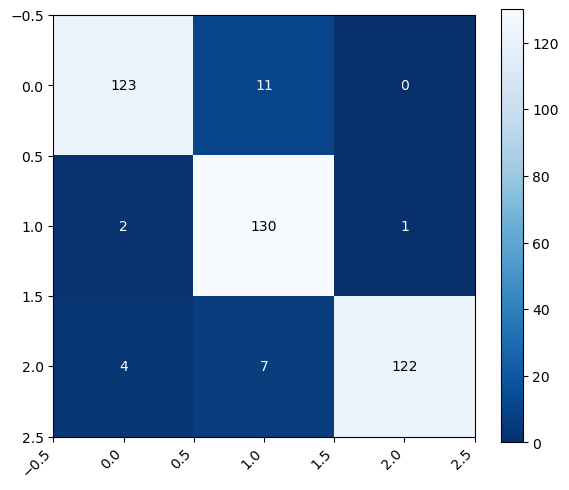

In [25]:
# B: Confusion Matrix Heatmap
all_labels = df_preds["true_label"].values
all_preds  = df_preds["predicted_label"].values
cm = confusion_matrix(all_labels, all_preds)
classes = [k for k,v in sorted(POLARITY2LABEL.items(), key=lambda x:x[1])]
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues_r', vmin=0, vmax=cm.max())
ax.figure.colorbar(im, ax=ax)
ax.grid(False)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] < thresh else "black"
        )
plt.tight_layout()
plt.show()


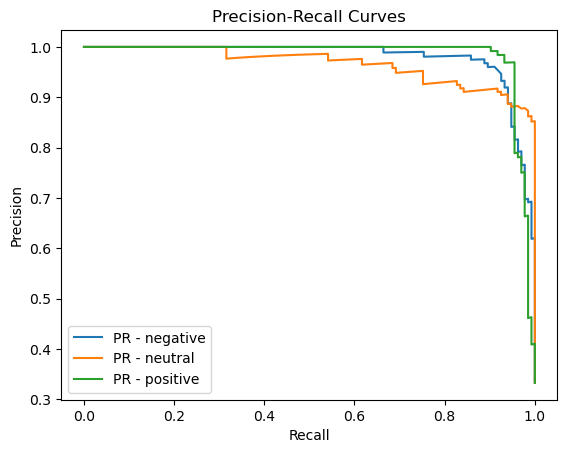

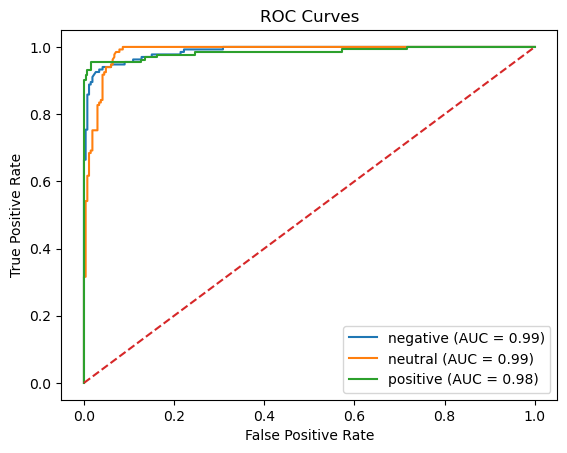

In [16]:
# C: Precision-Recall & ROC Curves per Class
plt.figure()
for idx, cls in enumerate(classes):
    y_true = (all_labels == idx).astype(int)
    probs_cls = []
    for batch in test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[:, idx]
        probs_cls.extend(probs)
    precision, recall, _ = precision_recall_curve(y_true, probs_cls)
    plt.plot(recall, precision, label=f"PR - {cls}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

plt.figure()
for idx, cls in enumerate(classes):
    y_true = (all_labels == idx).astype(int)
    probs_cls = []
    for batch in test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[:, idx]
        probs_cls.extend(probs)
    fpr, tpr, _ = roc_curve(y_true, probs_cls)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


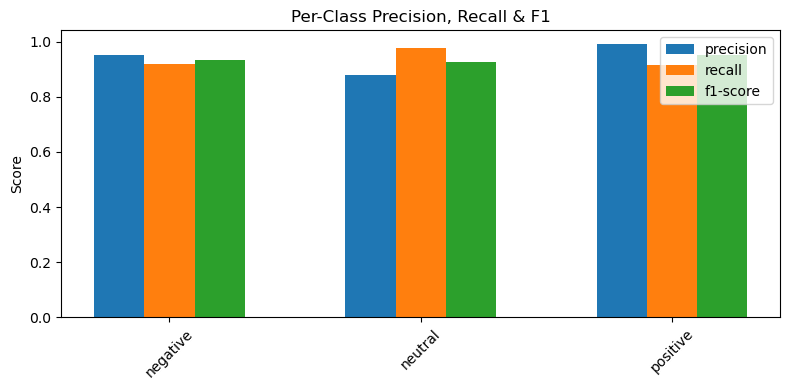

In [17]:
# D: Per-Class Precision/Recall/F1 Bar Chart
with open(os.path.join(save_dir, "test_results.json"), "r") as f:
    test_res = json.load(f)
report_dict = test_res["classification_report"]
metrics = ["precision", "recall", "f1-score"]
x = np.arange(len(classes))
bar_width = 0.2
plt.figure(figsize=(8,4))
for i, metric in enumerate(metrics):
    vals = [report_dict[cls][metric] for cls in classes]
    plt.bar(x + i*bar_width, vals, bar_width, label=metric)
plt.xticks(x + bar_width, classes, rotation=45)
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall & F1")
plt.legend()
plt.tight_layout()
plt.show()
